# Master's Thesis Notebook

This notebook is part of the **Master's Thesis (MSc Dissertation)**: **Fast Simulation of Neutrino Oscillations in Matter**.

**Author**  
Juan Ramon Diaz Santos <diazjuan@alumni.uv.es>

**Supervisors**  
Roberto Ruiz de Austri Bazan <rruiz@ific.uv.es>  
Michele Lucente <michele.lucente@unibo.it>

**Date**  
June 2026


# test6 atmosphere

Notebook equivalent of `tests/6_mceq/test6_atmosphere.py`. The original Python test module remains the source of truth; this notebook imports it and runs each numerical test and diagnostic plot in its own cell for interactive inspection.

The notebook uses the shared TPeanuts output-root convention defined in section `2. Paths`. Generated `mceq` test artifacts and figures are redirected to the notebook-specific `OUTPUT_DIR` under `OUTPUT_TEST_ROOT / "mceq" / NOTEBOOK_STEM`.


## 1. Libraries and test module

This section locates the repository, imports the original `mceq` test module, and reloads it so source changes are reflected when the notebook is rerun. The expected result is that the module imports without errors. Possible problems include running the notebook from outside the repository tree, missing optional dependencies, or unavailable external model data.


In [1]:
from __future__ import annotations

import importlib
import importlib.util
import os
import sys
import traceback
from pathlib import Path

import matplotlib.pyplot as plt


from tpeanuts.util.notebooks import find_repo_root
HERE = Path.cwd().resolve()
PACKAGE_DIR = find_repo_root(HERE, folder="analysis")
print(f"PACKAGE_DIR = {PACKAGE_DIR}")

NOTEBOOK_STEM = "test6_atmosphere"
TEST_MODULE_PATH = PACKAGE_DIR / "notebooks" / "tests" / "6_mceq" / f"{NOTEBOOK_STEM}.py"
TEST_MODULE_NAME = f"notebook_tests_{TEST_MODULE_PATH.parent.name.replace('.', '_')}_{NOTEBOOK_STEM}"
if not TEST_MODULE_PATH.exists():
    raise FileNotFoundError(f"Could not find local test module: {TEST_MODULE_PATH}")
spec = importlib.util.spec_from_file_location(TEST_MODULE_NAME, TEST_MODULE_PATH)
if spec is None or spec.loader is None:
    raise ImportError(f"Could not load test module spec from {TEST_MODULE_PATH}")
TEST_MODULE = importlib.util.module_from_spec(spec)
sys.modules[TEST_MODULE_NAME] = TEST_MODULE
spec.loader.exec_module(TEST_MODULE)
print("Loaded local test module:", TEST_MODULE_PATH)

from tpeanuts.util.notebooks import build_notebook_test_runner


PACKAGE_DIR = G:\Mi unidad\03.Codigo\034.TFM.UV\Tpeanuts
Loaded local test module: G:\Mi unidad\03.Codigo\034.TFM.UV\Tpeanuts\notebooks\tests\6_mceq\test6_atmosphere.py


## 2. Paths

All outputs are rooted at `DEFAULT_OUTPUT_ROOT` unless `TPEANUTS_OUTPUT_ROOT` is defined in the environment. This notebook writes `mceq` test figures and generated artifacts under `OUTPUT_TEST_ROOT / "mceq" / NOTEBOOK_STEM`, while data, analysis, benchmark, and external roots follow the same shared structure used by the analysis notebooks.


In [2]:
DEFAULT_OUTPUT_ROOT = Path(r"V:\output")
OUTPUT_ROOT = Path(os.environ.get("TPEANUTS_OUTPUT_ROOT", DEFAULT_OUTPUT_ROOT))

OUTPUT_DATA_ROOT = Path(OUTPUT_ROOT / "data")
OUTPUT_ANALYSIS_ROOT = Path(OUTPUT_ROOT / "analysis")
OUTPUT_BENCHMARK_ROOT = Path(OUTPUT_ROOT / "benchmark")
OUTPUT_TEST_ROOT = Path(OUTPUT_ROOT / "test")

OUTPUT_DATA_ATMOSPHERE = Path(OUTPUT_DATA_ROOT / "atmosphere")
OUTPUT_DATA_SOLAR = Path(OUTPUT_DATA_ROOT / "solar")
OUTPUT_DATA_EXTERNAL = Path(OUTPUT_DATA_ROOT / "external")

OUTPUT_ANALYSIS_ATMOSPHERE = Path(OUTPUT_ANALYSIS_ROOT / "atmosphere")
OUTPUT_ANALYSIS_SOLAR = Path(OUTPUT_ANALYSIS_ROOT / "solar")
OUTPUT_ANALYSIS_EXTERNAL = Path(OUTPUT_ANALYSIS_ROOT / "external")

OUTPUT_DATA_MCEQ = Path(OUTPUT_DATA_ROOT / "mceq")
OUTPUT_DATA_HONDA = Path(OUTPUT_DATA_ROOT / "honda")

OUTPUT_DIR = OUTPUT_TEST_ROOT / "mceq" / NOTEBOOK_STEM
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SHOW_PLOTS = True
print("Output root     :", OUTPUT_ROOT)
print("Output directory:", OUTPUT_DIR)


Output root     : V:\output
Output directory: V:\output\test\mceq\test6_atmosphere


In [3]:
NOTEBOOK_RUNNER_ATTRS = {}
if "RUN_REAL_DATA_ANALYSIS" in globals():
    NOTEBOOK_RUNNER_ATTRS["RUN_REAL_mceq_run1_analysis"] = RUN_REAL_DATA_ANALYSIS

runner = build_notebook_test_runner(
    TEST_MODULE,
    OUTPUT_DIR,
    show_plots=SHOW_PLOTS,
    auto_save_figures=True,
    extra_module_attrs=NOTEBOOK_RUNNER_ATTRS,
)
run_notebook_test = runner.run_test
run_notebook_call = runner.run_call


## Test: `test_get_density_model`

**What is checked:** Get density model behavior and numerical consistency.

**Expected result:** The expected result is a clean pass for these checks: assert_true.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; optional MCEq/crflux dependencies or atmospheric-model availability can affect this check.


In [4]:
run_notebook_test(TEST_MODULE.test_get_density_model)


Running test_get_density_model ...
MCEqRun::set_interaction_model(): SIBYLL23D
ParticleManager::_init_default_tracking(): Initializing default tracking categories (pi, K, mu)
MatrixBuilder::_fill_matrices(): No interactions by D_s- ((-431, 0)).
MatrixBuilder::_fill_matrices(): No interactions by D_s+ ((431, 0)).
MCEqRun::set_density_model(): Setting density profile to CORSIKA ('BK_USStd', None)
MCEqRun::set_primary_model(): Primary model set to Hillas-Gaisser (H3a)
MCEqRun::set_density_model(): Setting density profile to CORSIKA ('USStd', None)
density_model: <MCEq.geometry.density_profiles.CorsikaAtmosphere object at 0x00000256E9F35660>
------------------------------------------------------------------------------------------
PASSED: test_get_density_model


## Test: `test_get_density_model_rejects_bad_object`

**What is checked:** Get density model rejects bad object behavior and numerical consistency.

**Expected result:** The expected result is a clean pass for these checks: assert_raises.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; optional MCEq/crflux dependencies or atmospheric-model availability can affect this check.


In [5]:
run_notebook_test(TEST_MODULE.test_get_density_model_rejects_bad_object)


Running test_get_density_model_rejects_bad_object ...
------------------------------------------------------------------------------------------
PASSED: test_get_density_model_rejects_bad_object


## Test: `test_single_mass_density_positive`

**What is checked:** Single mass density positive behavior and numerical consistency.

**Expected result:** The expected result is a clean pass for these checks: assert_true.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; optional MCEq/crflux dependencies or atmospheric-model availability can affect this check.


In [6]:
run_notebook_test(TEST_MODULE.test_single_mass_density_positive)


Running test_single_mass_density_positive ...
MCEqRun::set_interaction_model(): SIBYLL23D
ParticleManager::_init_default_tracking(): Initializing default tracking categories (pi, K, mu)
MatrixBuilder::_fill_matrices(): No interactions by D_s- ((-431, 0)).
MatrixBuilder::_fill_matrices(): No interactions by D_s+ ((431, 0)).
MCEqRun::set_density_model(): Setting density profile to CORSIKA ('BK_USStd', None)
MCEqRun::set_primary_model(): Primary model set to Hillas-Gaisser (H3a)
MCEqRun::set_density_model(): Setting density profile to CORSIKA ('USStd', None)
rho(0 km)  = 0.0012298058237329703
rho(20 km) = 8.848197332765202e-05
------------------------------------------------------------------------------------------
PASSED: test_single_mass_density_positive


## Test: `test_single_mass_overburden_positive_if_available`

**What is checked:** Single mass overburden positive if available behavior and numerical consistency.

**Expected result:** The expected result is a clean pass for these checks: assert_true.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; optional MCEq/crflux dependencies or atmospheric-model availability can affect this check.


In [7]:
run_notebook_test(TEST_MODULE.test_single_mass_overburden_positive_if_available)


Running test_single_mass_overburden_positive_if_available ...
MCEqRun::set_interaction_model(): SIBYLL23D
ParticleManager::_init_default_tracking(): Initializing default tracking categories (pi, K, mu)
MatrixBuilder::_fill_matrices(): No interactions by D_s- ((-431, 0)).
MatrixBuilder::_fill_matrices(): No interactions by D_s+ ((431, 0)).
MCEqRun::set_density_model(): Setting density profile to CORSIKA ('BK_USStd', None)
MCEqRun::set_primary_model(): Primary model set to Hillas-Gaisser (H3a)
MCEqRun::set_density_model(): Setting density profile to CORSIKA ('USStd', None)
X(0 km)  = 1036.1
X(20 km) = 56.900081497851474
------------------------------------------------------------------------------------------
PASSED: test_single_mass_overburden_positive_if_available


## Test: `test_density_profile_shape_and_positive`

**What is checked:** Density profile shape and positive behavior and numerical consistency.

**Expected result:** The expected result is a clean pass for these checks: assert_true.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; optional MCEq/crflux dependencies or atmospheric-model availability can affect this check.


In [8]:
run_notebook_test(TEST_MODULE.test_density_profile_shape_and_positive)


Running test_density_profile_shape_and_positive ...
MCEqRun::set_interaction_model(): SIBYLL23D
ParticleManager::_init_default_tracking(): Initializing default tracking categories (pi, K, mu)
MatrixBuilder::_fill_matrices(): No interactions by D_s- ((-431, 0)).
MatrixBuilder::_fill_matrices(): No interactions by D_s+ ((431, 0)).
MCEqRun::set_density_model(): Setting density profile to CORSIKA ('BK_USStd', None)
MCEqRun::set_primary_model(): Primary model set to Hillas-Gaisser (H3a)
MCEqRun::set_density_model(): Setting density profile to CORSIKA ('USStd', None)
h shape  : torch.Size([200])
rho shape: torch.Size([200])
rho min  : 1.6614456410505888e-09
rho max  : 0.0012298058237329703
------------------------------------------------------------------------------------------
PASSED: test_density_profile_shape_and_positive


## Test: `test_density_profile_decreases_approximately`

**What is checked:** Density profile decreases approximately behavior and numerical consistency.

**Expected result:** The expected result is a clean pass for these checks: assert_true.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; optional MCEq/crflux dependencies or atmospheric-model availability can affect this check.


In [9]:
run_notebook_test(TEST_MODULE.test_density_profile_decreases_approximately)


Running test_density_profile_decreases_approximately ...
MCEqRun::set_interaction_model(): SIBYLL23D
ParticleManager::_init_default_tracking(): Initializing default tracking categories (pi, K, mu)
MatrixBuilder::_fill_matrices(): No interactions by D_s- ((-431, 0)).
MatrixBuilder::_fill_matrices(): No interactions by D_s+ ((431, 0)).
MCEqRun::set_density_model(): Setting density profile to CORSIKA ('BK_USStd', None)
MCEqRun::set_primary_model(): Primary model set to Hillas-Gaisser (H3a)
MCEqRun::set_density_model(): Setting density profile to CORSIKA ('USStd', None)
rho(0 km)   = 0.0012298058237329703
rho(100 km) = 1.6614456410505888e-09
------------------------------------------------------------------------------------------
PASSED: test_density_profile_decreases_approximately


## Test: `test_overburden_profile_shape_and_positive`

**What is checked:** Overburden profile shape and positive behavior and numerical consistency.

**Expected result:** The expected result is a clean pass for these checks: assert_true.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; optional MCEq/crflux dependencies or atmospheric-model availability can affect this check.


In [10]:
run_notebook_test(TEST_MODULE.test_overburden_profile_shape_and_positive)


Running test_overburden_profile_shape_and_positive ...
MCEqRun::set_interaction_model(): SIBYLL23D
ParticleManager::_init_default_tracking(): Initializing default tracking categories (pi, K, mu)
MatrixBuilder::_fill_matrices(): No interactions by D_s- ((-431, 0)).
MatrixBuilder::_fill_matrices(): No interactions by D_s+ ((431, 0)).
MCEqRun::set_density_model(): Setting density profile to CORSIKA ('BK_USStd', None)
MCEqRun::set_primary_model(): Primary model set to Hillas-Gaisser (H3a)
MCEqRun::set_density_model(): Setting density profile to CORSIKA ('USStd', None)
h shape: torch.Size([200])
X shape: torch.Size([200])
X min  : 0.001282918480650033
X max  : 1036.1
------------------------------------------------------------------------------------------
PASSED: test_overburden_profile_shape_and_positive


## Test: `test_overburden_profile_decreases_with_height`

**What is checked:** Overburden profile decreases with height behavior and numerical consistency.

**Expected result:** The expected result is a clean pass for these checks: assert_true.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; optional MCEq/crflux dependencies or atmospheric-model availability can affect this check.


In [11]:
run_notebook_test(TEST_MODULE.test_overburden_profile_decreases_with_height)


Running test_overburden_profile_decreases_with_height ...
MCEqRun::set_interaction_model(): SIBYLL23D
ParticleManager::_init_default_tracking(): Initializing default tracking categories (pi, K, mu)
MatrixBuilder::_fill_matrices(): No interactions by D_s- ((-431, 0)).
MatrixBuilder::_fill_matrices(): No interactions by D_s+ ((431, 0)).
MCEqRun::set_density_model(): Setting density profile to CORSIKA ('BK_USStd', None)
MCEqRun::set_primary_model(): Primary model set to Hillas-Gaisser (H3a)
MCEqRun::set_density_model(): Setting density profile to CORSIKA ('USStd', None)
max dX: -8.626630503158115e-05
min dX: -60.263446879237335
------------------------------------------------------------------------------------------
PASSED: test_overburden_profile_decreases_with_height


## Test: `test_profile_functions_can_initialize_mceq_internally`

**What is checked:** Profile functions can initialize mceq internally behavior and numerical consistency.

**Expected result:** The expected result is a clean pass for these checks: assert_true.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; optional MCEq/crflux dependencies or atmospheric-model availability can affect this check; solver tests may fail when optional external MCEq data or packages are not installed.


In [12]:
run_notebook_test(TEST_MODULE.test_profile_functions_can_initialize_mceq_internally)


Running test_profile_functions_can_initialize_mceq_internally ...
MCEqRun::set_interaction_model(): SIBYLL23D
ParticleManager::_init_default_tracking(): Initializing default tracking categories (pi, K, mu)
MatrixBuilder::_fill_matrices(): No interactions by D_s- ((-431, 0)).
MatrixBuilder::_fill_matrices(): No interactions by D_s+ ((431, 0)).
MCEqRun::set_density_model(): Setting density profile to CORSIKA ('BK_USStd', None)
MCEqRun::set_primary_model(): Primary model set to Hillas-Gaisser (H3a)
MCEqRun::set_density_model(): Setting density profile to CORSIKA ('USStd', None)
MCEqRun::set_interaction_model(): SIBYLL23D
ParticleManager::_init_default_tracking(): Initializing default tracking categories (pi, K, mu)
MatrixBuilder::_fill_matrices(): No interactions by D_s- ((-431, 0)).
MatrixBuilder::_fill_matrices(): No interactions by D_s+ ((431, 0)).
MCEqRun::set_density_model(): Setting density profile to CORSIKA ('BK_USStd', None)
MCEqRun::set_primary_model(): Primary model set to Hill

## Test: `test_density_scalar_input_returns_scalar_shape`

**What is checked:** Density scalar input returns scalar shape behavior and numerical consistency.

**Expected result:** The expected result is a clean pass for these checks: assert_true.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; optional MCEq/crflux dependencies or atmospheric-model availability can affect this check.


In [13]:
run_notebook_test(TEST_MODULE.test_density_scalar_input_returns_scalar_shape)


Running test_density_scalar_input_returns_scalar_shape ...
MCEqRun::set_interaction_model(): SIBYLL23D
ParticleManager::_init_default_tracking(): Initializing default tracking categories (pi, K, mu)
MatrixBuilder::_fill_matrices(): No interactions by D_s- ((-431, 0)).
MatrixBuilder::_fill_matrices(): No interactions by D_s+ ((431, 0)).
MCEqRun::set_density_model(): Setting density profile to CORSIKA ('BK_USStd', None)
MCEqRun::set_primary_model(): Primary model set to Hillas-Gaisser (H3a)
MCEqRun::set_density_model(): Setting density profile to CORSIKA ('USStd', None)
rho: tensor(0.0004, dtype=torch.float64)
rho shape: torch.Size([])
------------------------------------------------------------------------------------------
PASSED: test_density_scalar_input_returns_scalar_shape


## Test: `test_save_mceq_density_profile_creates_file`

**What is checked:** Save mceq density profile creates file behavior and numerical consistency.

**Expected result:** The expected result is a clean pass for these checks: assert_true.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; optional MCEq/crflux dependencies or atmospheric-model availability can affect this check; solver tests may fail when optional external MCEq data or packages are not installed.


In [14]:
run_notebook_test(TEST_MODULE.test_save_mceq_density_profile_creates_file)


Running test_save_mceq_density_profile_creates_file ...
MCEqRun::set_interaction_model(): SIBYLL23D
ParticleManager::_init_default_tracking(): Initializing default tracking categories (pi, K, mu)
MatrixBuilder::_fill_matrices(): No interactions by D_s- ((-431, 0)).
MatrixBuilder::_fill_matrices(): No interactions by D_s+ ((431, 0)).
MCEqRun::set_density_model(): Setting density profile to CORSIKA ('BK_USStd', None)
MCEqRun::set_primary_model(): Primary model set to Hillas-Gaisser (H3a)
MCEqRun::set_density_model(): Setting density profile to CORSIKA ('USStd', None)
saved path: C:\Users\juanr\AppData\Local\Temp\tpeanuts_atmosphere_test_tinsx9m0\density_profile.txt
number of lines: 23
first data line: 0.0000000000e+00    1.2298058237e-03
------------------------------------------------------------------------------------------
PASSED: test_save_mceq_density_profile_creates_file


## Test: `test_save_mceq_density_profile_overwrite_false_raises`

**What is checked:** Save mceq density profile overwrite false raises behavior and numerical consistency.

**Expected result:** The expected result is a clean pass for these checks: assert_raises.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; optional MCEq/crflux dependencies or atmospheric-model availability can affect this check; solver tests may fail when optional external MCEq data or packages are not installed.


In [15]:
run_notebook_test(TEST_MODULE.test_save_mceq_density_profile_overwrite_false_raises)


Running test_save_mceq_density_profile_overwrite_false_raises ...
------------------------------------------------------------------------------------------
PASSED: test_save_mceq_density_profile_overwrite_false_raises


## Plot: `plot_density_profile()`

**What is checked:** Density profile behavior and numerical consistency.

**Expected result:** The expected result is that the diagnostic plot call completes and writes its figure output to `OUTPUT_DIR`.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; optional MCEq/crflux dependencies or atmospheric-model availability can affect this check; missing or blank plots may indicate a path, backend, or non-finite numerical-data problem.


### Output files for `plot_density_profile()`

This block generates or validates files in `OUTPUT_DIR`:

- `plot_density_profile_figure_001.png`

The expected result is that each relevant image or data artifact is written to disk and, for figures, also displayed inline when `SHOW_PLOTS = True`. Possible problems include a non-writable output directory, an inactive Matplotlib backend, missing optional external data, or upstream numerical values that make the plotted curves empty or non-finite.


Running plot_density_profile() ...
MCEqRun::set_interaction_model(): SIBYLL23D
ParticleManager::_init_default_tracking(): Initializing default tracking categories (pi, K, mu)
MatrixBuilder::_fill_matrices(): No interactions by D_s- ((-431, 0)).
MatrixBuilder::_fill_matrices(): No interactions by D_s+ ((431, 0)).
MCEqRun::set_density_model(): Setting density profile to CORSIKA ('BK_USStd', None)
MCEqRun::set_primary_model(): Primary model set to Hillas-Gaisser (H3a)
MCEqRun::set_density_model(): Setting density profile to CORSIKA ('USStd', None)
Saved plot: V:\output\test\mceq\test6_atmosphere\plot_density_profile_figure_001.png


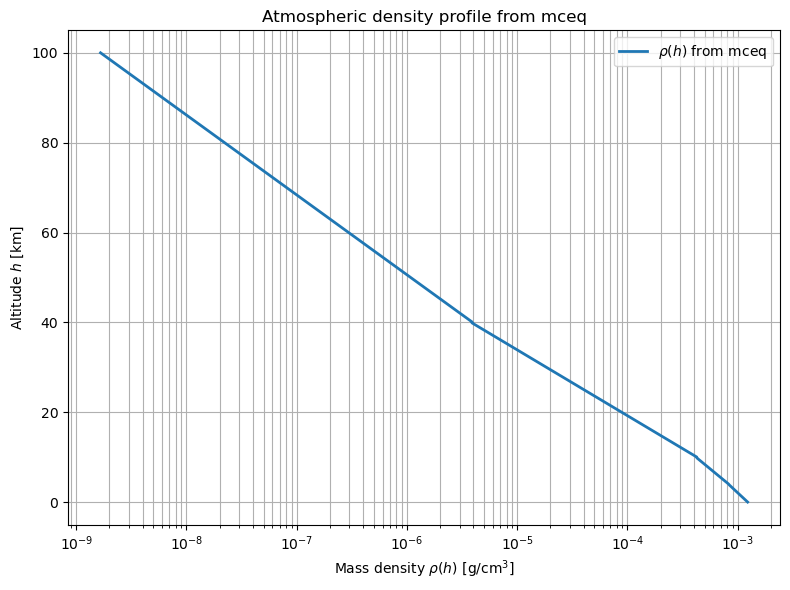

PASSED: plot_density_profile()


In [16]:
run_notebook_call('plot_density_profile()', lambda: TEST_MODULE.plot_density_profile())


## Plot: `plot_overburden_profile()`

**What is checked:** Overburden profile behavior and numerical consistency.

**Expected result:** The expected result is that the diagnostic plot call completes and writes its figure output to `OUTPUT_DIR`.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; optional MCEq/crflux dependencies or atmospheric-model availability can affect this check; missing or blank plots may indicate a path, backend, or non-finite numerical-data problem.


### Output files for `plot_overburden_profile()`

This block generates or validates files in `OUTPUT_DIR`:

- `plot_overburden_profile_figure_001.png`

The expected result is that each relevant image or data artifact is written to disk and, for figures, also displayed inline when `SHOW_PLOTS = True`. Possible problems include a non-writable output directory, an inactive Matplotlib backend, missing optional external data, or upstream numerical values that make the plotted curves empty or non-finite.


Running plot_overburden_profile() ...
MCEqRun::set_interaction_model(): SIBYLL23D
ParticleManager::_init_default_tracking(): Initializing default tracking categories (pi, K, mu)
MatrixBuilder::_fill_matrices(): No interactions by D_s- ((-431, 0)).
MatrixBuilder::_fill_matrices(): No interactions by D_s+ ((431, 0)).
MCEqRun::set_density_model(): Setting density profile to CORSIKA ('BK_USStd', None)
MCEqRun::set_primary_model(): Primary model set to Hillas-Gaisser (H3a)
MCEqRun::set_density_model(): Setting density profile to CORSIKA ('USStd', None)
Saved plot: V:\output\test\mceq\test6_atmosphere\plot_overburden_profile_figure_001.png


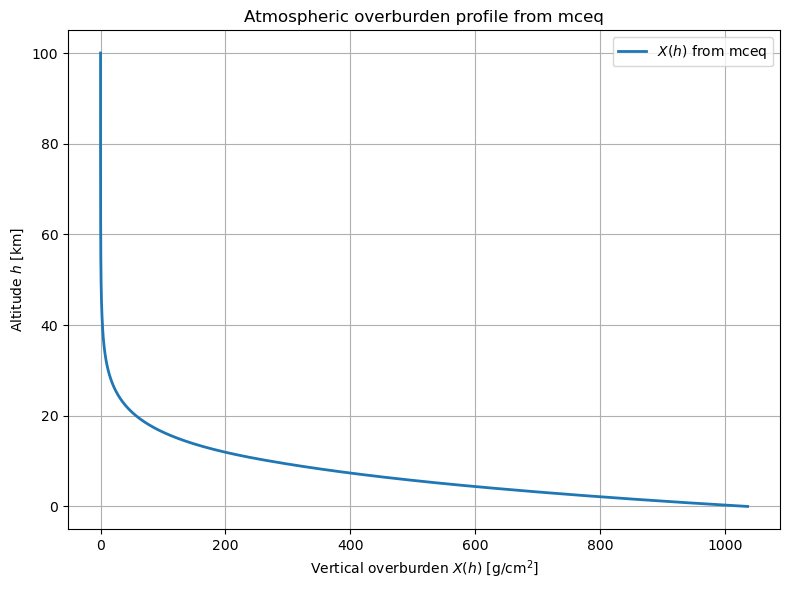

PASSED: plot_overburden_profile()


In [17]:
run_notebook_call('plot_overburden_profile()', lambda: TEST_MODULE.plot_overburden_profile())


## Plot: `plot_density_and_overburden_together()`

**What is checked:** Density and overburden together behavior and numerical consistency.

**Expected result:** The expected result is that the diagnostic plot call completes and writes its figure output to `OUTPUT_DIR`.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; optional MCEq/crflux dependencies or atmospheric-model availability can affect this check; missing or blank plots may indicate a path, backend, or non-finite numerical-data problem.


### Output files for `plot_density_and_overburden_together()`

This block generates or validates files in `OUTPUT_DIR`:

- `plot_density_and_overburden_together_figure_001.png`

The expected result is that each relevant image or data artifact is written to disk and, for figures, also displayed inline when `SHOW_PLOTS = True`. Possible problems include a non-writable output directory, an inactive Matplotlib backend, missing optional external data, or upstream numerical values that make the plotted curves empty or non-finite.


Running plot_density_and_overburden_together() ...
MCEqRun::set_interaction_model(): SIBYLL23D
ParticleManager::_init_default_tracking(): Initializing default tracking categories (pi, K, mu)
MatrixBuilder::_fill_matrices(): No interactions by D_s- ((-431, 0)).
MatrixBuilder::_fill_matrices(): No interactions by D_s+ ((431, 0)).
MCEqRun::set_density_model(): Setting density profile to CORSIKA ('BK_USStd', None)
MCEqRun::set_primary_model(): Primary model set to Hillas-Gaisser (H3a)
MCEqRun::set_density_model(): Setting density profile to CORSIKA ('USStd', None)
Saved plot: V:\output\test\mceq\test6_atmosphere\plot_density_and_overburden_together_figure_001.png


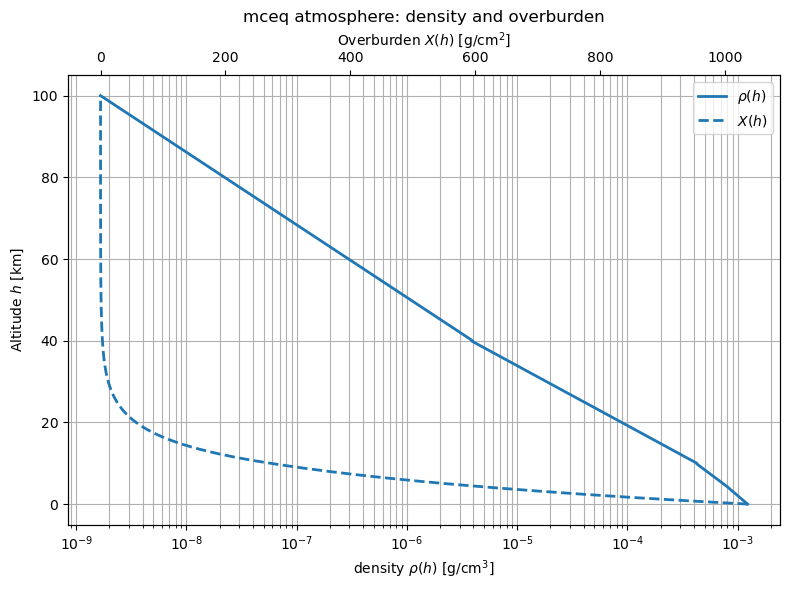

PASSED: plot_density_and_overburden_together()


In [18]:
run_notebook_call('plot_density_and_overburden_together()', lambda: TEST_MODULE.plot_density_and_overburden_together())
